In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../'))

import numpy as np
import tensorflow as tf
import random, json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')

WEIGHTS_DIR       = '../../weights/cnn'
RESULTS_TABLE_DIR = '../../results/tables'
RESULTS_PLOT_DIR  = '../../results/plots'
INTEL_TEST_DIR    = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

os.makedirs(RESULTS_TABLE_DIR, exist_ok=True)
os.makedirs(RESULTS_PLOT_DIR,  exist_ok=True)

from src.cnn.evaluate import ModelEvaluator
print('Setup OK')

2026-05-15 06:08:19.636514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778825299.658333     150 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778825299.665523     150 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778825299.682309     150 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778825299.682327     150 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778825299.682330     150 computation_placer.cc:177] computation placer alr

Setup OK


## 1. Muat Hasil Training (F1 + Loss Histories)

In [2]:
results_path = os.path.join(WEIGHTS_DIR, 'training_results.json')

with open(results_path) as f:
    cnn_results = json.load(f)

# Flatten semua variant ke satu dict
all_variants = {}
for group, variants in cnn_results.items():
    for name, info in variants.items():
        all_variants[name] = info

# Build histories dict langsung dari training_results.json
cnn_histories = {name: info['history'] for name, info in all_variants.items()}

df_results = pd.DataFrame([
    {'model': k, 'macro_f1': v['macro_f1']}
    for k, v in all_variants.items()
]).sort_values('macro_f1', ascending=False)

display(df_results)
best_model_name = df_results.iloc[0]['model']
print(f'\nArsitektur terbaik: {best_model_name}  (F1={df_results.iloc[0]["macro_f1"]:.4f})')

,model,macro_f1
14,conv2d_L3_F2_K2_Pmax,0.876865
10,conv2d_L3_F1_K2_Pmax,0.875360
15,conv2d_L3_F2_K2_Pavg,0.861488
8,conv2d_L3_F1_K1_Pmax,0.861446
12,conv2d_L3_F2_K1_Pmax,0.860821
11,conv2d_L3_F1_K2_Pavg,0.854292
13,conv2d_L3_F2_K1_Pavg,0.847938
6,conv2d_L2_F2_K2_Pmax,0.832454
9,conv2d_L3_F1_K1_Pavg,0.832408
2,conv2d_L2_F1_K2_Pmax,0.826441



Arsitektur terbaik: conv2d_L3_F2_K2_Pmax  (F1=0.8769)


## 2. Load Test Dataset

In [3]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    INTEL_TEST_DIR,
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))
NUM_CLASSES = len(class_names)
print(f'Classes ({NUM_CLASSES}): {class_names}')

Found 3000 files belonging to 6 classes.


I0000 00:00:1778825323.670761     150 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778825323.676666     150 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 3. Forward Propagation From Scratch — Arsitektur Terbaik (Conv2D Shared)

In [4]:
evaluator = ModelEvaluator(WEIGHTS_DIR)

best_result = evaluator.evaluate_model_pair(best_model_name, test_ds)

print(f'\nModel: {best_model_name}')
print(f'  Keras  macro F1 : {best_result["keras_metrics"]["macro_f1"]:.4f}')
print(f'  Scratch macro F1: {best_result["from_scratch_metrics"]["macro_f1"]:.4f}')
print(f'  Predictions match (atol=1e-5): {best_result["predictions_match"]}')
print(f'  Parameter count : {best_result["parameter_count"]:,}')

I0000 00:00:1778825326.586246     202 service.cc:152] XLA service 0x7cc3f8009e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778825326.586296     202 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778825326.586303     202 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778825326.720835     202 cuda_dnn.cc:529] Loaded cuDNN version 91002


I0000 00:00:1778825333.968547     202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Model: conv2d_L3_F2_K2_Pmax
  Keras  macro F1 : 0.8769
  Scratch macro F1: 0.8769
  Predictions match (atol=1e-5): False
  Parameter count : 1,096,582


## 4. Ganti Conv2D → LocallyConnected2D (Non-Shared)

In [5]:
LC_MODEL_NAME = 'locally_connected2d_best'
lc_path = os.path.join(WEIGHTS_DIR, f'{LC_MODEL_NAME}.h5')

if os.path.exists(lc_path):
    lc_result = evaluator.evaluate_model_pair(LC_MODEL_NAME, test_ds)
    print(f'Model: {LC_MODEL_NAME}')
    print(f'  Keras  macro F1 : {lc_result["keras_metrics"]["macro_f1"]:.4f}')
    print(f'  Scratch macro F1: {lc_result["from_scratch_metrics"]["macro_f1"]:.4f}')
    print(f'  Predictions match: {lc_result["predictions_match"]}')
    print(f'  Parameter count : {lc_result["parameter_count"]:,}')
else:
    print(f'Model {lc_path} tidak ditemukan — pastikan training FASE 1 sudah selesai')
    lc_result = None

Model: locally_connected2d_best
  Keras  macro F1 : 0.6594
  Scratch macro F1: 0.6594
  Predictions match: False
  Parameter count : 152,558,086


## 5. Tabel Perbandingan: Shared vs Non-Shared

In [6]:
rows = [
    {
        'model':        best_model_name,
        'type':         'Conv2D (shared)',
        'keras_f1':     round(best_result['keras_metrics']['macro_f1'], 4),
        'scratch_f1':   round(best_result['from_scratch_metrics']['macro_f1'], 4),
        'params':       best_result['parameter_count'],
        'preds_match':  best_result['predictions_match'],
    }
]

if lc_result:
    rows.append({
        'model':        LC_MODEL_NAME,
        'type':         'LocallyConnected2D (non-shared)',
        'keras_f1':     round(lc_result['keras_metrics']['macro_f1'], 4),
        'scratch_f1':   round(lc_result['from_scratch_metrics']['macro_f1'], 4),
        'params':       lc_result['parameter_count'],
        'preds_match':  lc_result['predictions_match'],
    })

df_cmp = pd.DataFrame(rows)
display(df_cmp)

with open(os.path.join(RESULTS_TABLE_DIR, 'cnn_shared_vs_nonshared.json'), 'w') as f:
    json.dump(rows, f, indent=2)

,model,type,keras_f1,scratch_f1,params,preds_match
0,conv2d_L3_F2_K2_Pmax,Conv2D (shared),0.8769,0.8769,1096582,False
1,locally_connected2d_best,LocallyConnected2D (non-shared),0.6594,0.6594,152558086,False


## 5.1 Keras vs From-Scratch — Perbandingan Detail

In [ ]:
# Kumpulkan semua hasil evaluasi yang sudah ada
eval_results = {best_model_name: best_result}
if lc_result:
    eval_results['locally_connected2d_best'] = lc_result

# Bangun dataframe Keras vs Scratch per model
ks_rows = []
for name, res in eval_results.items():
    km = res['keras_metrics']
    sm = res['from_scratch_metrics']
    ks_rows.append({
        'model':         name,
        'type':          'Conv2D (shared)' if 'locally' not in name else 'LocallyConnected2D (non-shared)',
        'keras_f1':      round(km['macro_f1'], 4),
        'scratch_f1':    round(sm['macro_f1'], 4),
        'keras_acc':     round(km['accuracy'], 4),
        'scratch_acc':   round(sm['accuracy'], 4),
        'f1_delta':      round(abs(km['macro_f1'] - sm['macro_f1']), 6),
        'acc_delta':     round(abs(km['accuracy'] - sm['accuracy']), 6),
        'preds_match':   res['predictions_match'],
        'params':        res['parameter_count'],
    })

df_ks = pd.DataFrame(ks_rows)
print("=== Keras vs From-Scratch (macro F1 & Accuracy) ===")
display(df_ks[['model', 'type', 'keras_f1', 'scratch_f1', 'f1_delta',
               'keras_acc', 'scratch_acc', 'acc_delta', 'preds_match']])

x       = np.arange(len(df_ks))
width   = 0.2
labels  = [r['model'].replace('conv2d_', '').replace('locally_connected2d_', 'lc_')
           for r in ks_rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in zip(axes,
                              [('keras_f1', 'scratch_f1'),
                               ('keras_acc', 'scratch_acc')],
                              ['Macro F1-Score', 'Accuracy']):
    keras_vals   = df_ks[metric[0]].values
    scratch_vals = df_ks[metric[1]].values

    b1 = ax.bar(x - width/2, keras_vals,   width, label='Keras',       color='#4C72B0', alpha=0.85)
    b2 = ax.bar(x + width/2, scratch_vals, width, label='From Scratch', color='#DD8452', alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.4f}', ha='center', va='bottom', fontsize=8)

    # delta annotation
    for i, (kv, sv) in enumerate(zip(keras_vals, scratch_vals)):
        delta = abs(kv - sv)
        ymax  = max(kv, sv)
        ax.annotate(f'Δ={delta:.4f}',
                    xy=(x[i], ymax + 0.025),
                    ha='center', va='bottom', fontsize=8,
                    color='grey', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel(title, fontsize=11)
    ax.legend()

fig.suptitle('Keras vs From-Scratch: Metric Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOT_DIR, 'cnn_keras_vs_scratch.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Simpan tabel ──────────────────────────────────────────────────────────────
df_ks.to_json(os.path.join(RESULTS_TABLE_DIR, 'cnn_keras_vs_scratch.json'),
              orient='records', indent=2)
print('\nTabel disimpan ke results/tables/cnn_keras_vs_scratch.json')
print('Plot disimpan ke results/plots/cnn_keras_vs_scratch.png')

## 6. Plot: Training/Val Loss per Hyperparameter

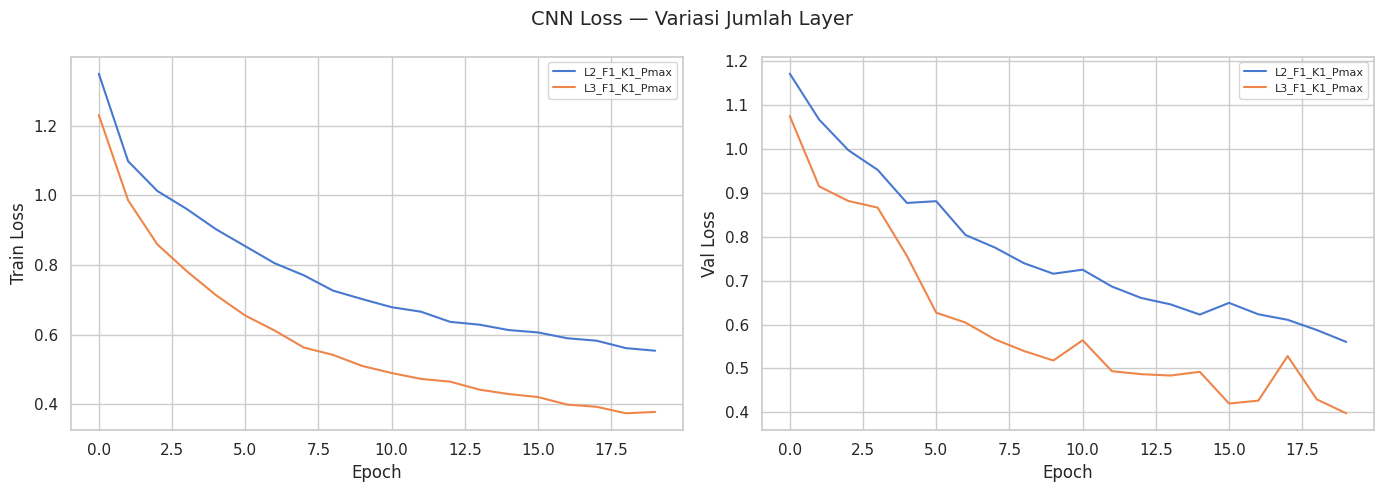

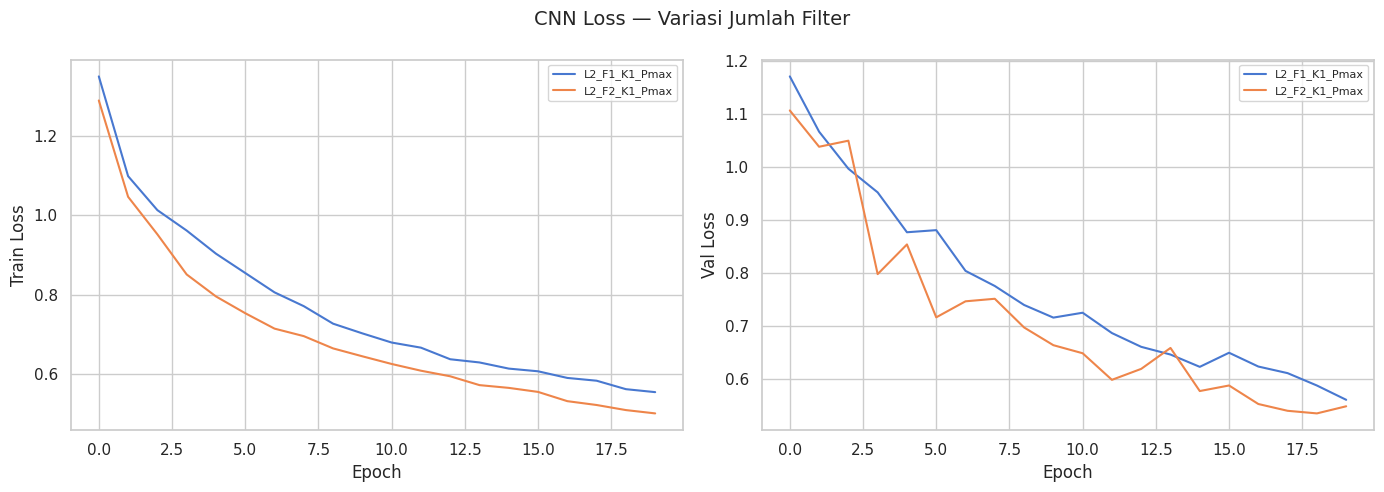

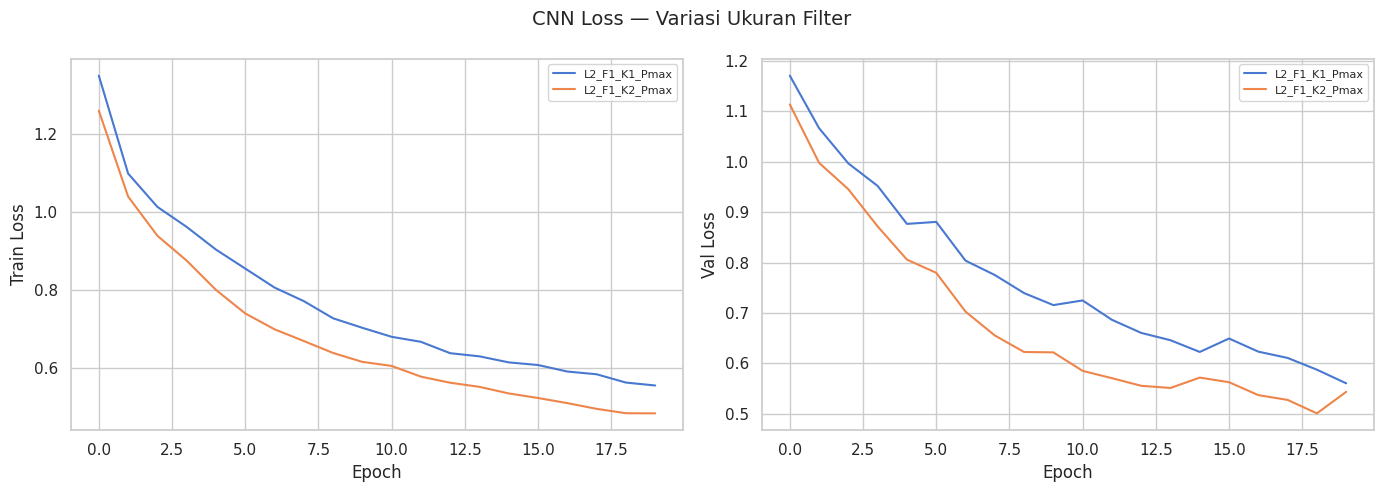

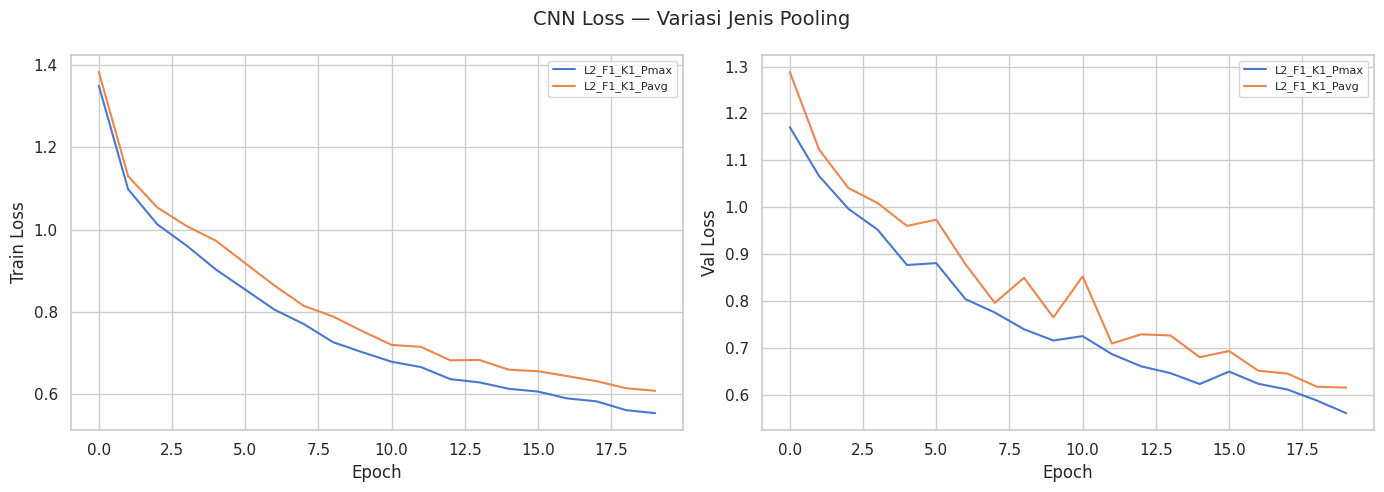

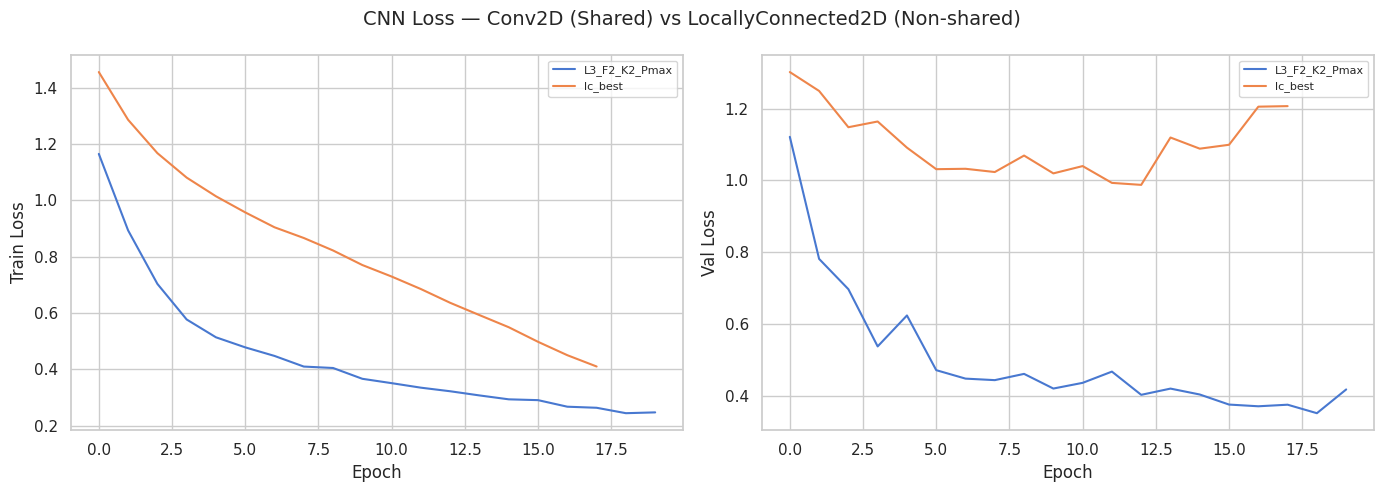

In [7]:
def plot_loss_group(group_histories: dict, title: str, save_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, h in group_histories.items():
        label = name.replace('conv2d_', '').replace('locally_connected2d_', 'lc_')
        axes[0].plot(h['loss'],     label=label)
        axes[1].plot(h['val_loss'], label=label)
    for ax, ylabel in zip(axes, ['Train Loss', 'Val Loss']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Variasi jumlah layer
layer_hist = {k: v for k, v in cnn_histories.items() if '_F1_K1_Pmax' in k}
if layer_hist:
    plot_loss_group(layer_hist, 'CNN Loss — Variasi Jumlah Layer',
                    os.path.join(RESULTS_PLOT_DIR, 'cnn_loss_num_layers.png'))

# Variasi jumlah filter
filter_hist = {k: v for k, v in cnn_histories.items() if 'L2_' in k and '_K1_Pmax' in k}
if filter_hist:
    plot_loss_group(filter_hist, 'CNN Loss — Variasi Jumlah Filter',
                    os.path.join(RESULTS_PLOT_DIR, 'cnn_loss_num_filters.png'))

# Variasi ukuran kernel
kernel_hist = {k: v for k, v in cnn_histories.items() if 'L2_F1_' in k and '_Pmax' in k}
if kernel_hist:
    plot_loss_group(kernel_hist, 'CNN Loss — Variasi Ukuran Filter',
                    os.path.join(RESULTS_PLOT_DIR, 'cnn_loss_filter_size.png'))

# Variasi pooling
pool_hist = {k: v for k, v in cnn_histories.items() if 'L2_F1_K1_' in k}
if pool_hist:
    plot_loss_group(pool_hist, 'CNN Loss — Variasi Jenis Pooling',
                    os.path.join(RESULTS_PLOT_DIR, 'cnn_loss_pooling_type.png'))

# Shared vs Non-shared
lc_hist = {k: v for k, v in cnn_histories.items() if 'locally' in k}
shared_hist = {k: v for k, v in cnn_histories.items() if best_model_name == k}
if shared_hist or lc_hist:
    plot_loss_group({**shared_hist, **lc_hist},
                    'CNN Loss — Conv2D (Shared) vs LocallyConnected2D (Non-shared)',
                    os.path.join(RESULTS_PLOT_DIR, 'cnn_shared_vs_nonshared.png'))

## 7. Bar Chart: Macro F1 Semua Variasi

/tmp/ipykernel_150/1048249316.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)


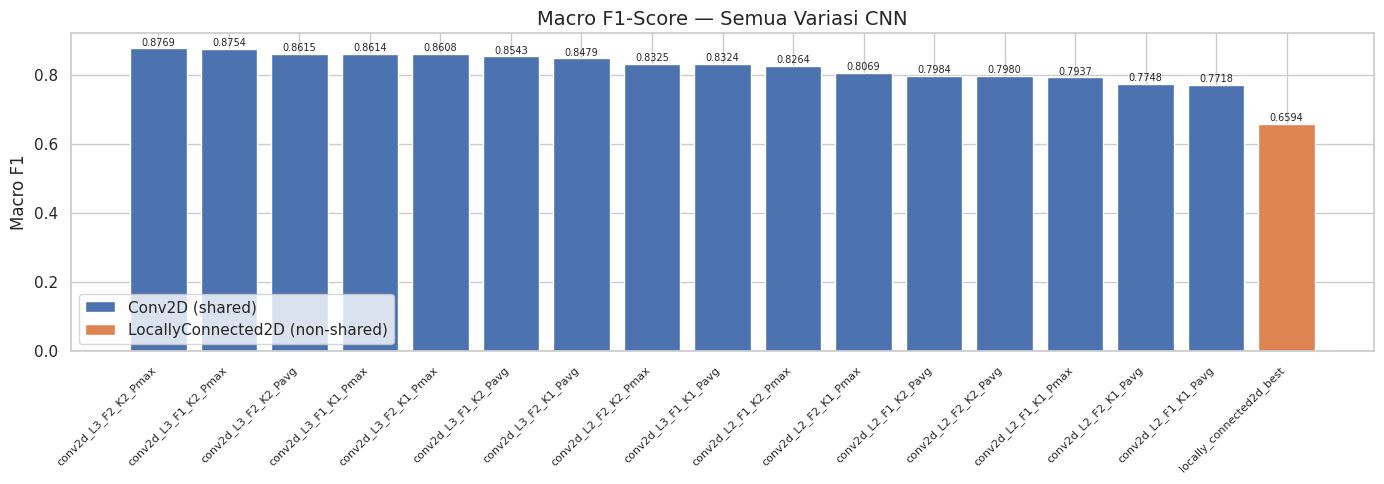

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
names  = df_results['model'].tolist()
f1s    = df_results['macro_f1'].tolist()
colors = ['#DD8452' if 'locally' in n else '#4C72B0' for n in names]

bars = ax.bar(names, f1s, color=colors)
ax.set_title('Macro F1-Score — Semua Variasi CNN', fontsize=14)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C72B0', label='Conv2D (shared)'),
    Patch(facecolor='#DD8452', label='LocallyConnected2D (non-shared)'),
])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOT_DIR, 'cnn_f1_all_variants.png'), dpi=150, bbox_inches='tight')
plt.show()